In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)

In [3]:
def quantize_at_bitwidth(tensor, bits):
    """
    Performs symmetric quantization for a given bit width.
    Returns:
        quantized_tensor
        dequantized_tensor
        scale
        q_min
        q_max
    """
    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1
    max_abs = np.max(np.abs(tensor))
    scale = max_abs / q_max
    quantized = np.round(tensor / scale)
    quantized = np.clip(quantized, q_min, q_max)
    quantized = quantized.astype(np.int8)
    dequantized = quantized.astype(np.float32) * scale
    return quantized, dequantized, scale, q_min, q_max

In [4]:
def calculate_errors(original, reconstructed):
    error = np.abs(original - reconstructed)
    mae = np.mean(error)
    mse = np.mean((original - reconstructed) ** 2)
    max_error = np.max(error)
    return mae, mse, max_error

In [5]:
bit_widths = [8, 6, 4]
results = {}
for bits in bit_widths:
    quantized, dequantized, scale, q_min, q_max = quantize_at_bitwidth(tensor, bits)
    mae, mse, max_error = calculate_errors(tensor, dequantized)
    results[bits] = {
        "quantized": quantized,
        "dequantized": dequantized,
        "scale": scale,
        "mae": mae,
        "mse": mse,
        "max_error": max_error,
        "q_min": q_min,
        "q_max": q_max
    }

In [6]:
for bits in bit_widths:
    print("="*60)
    print(f"{bits}-Bit Quantization")
    print("="*60)
    print("q_min:", results[bits]["q_min"])
    print("q_max:", results[bits]["q_max"])
    print("Representable Levels:",
          results[bits]["q_max"] - results[bits]["q_min"] + 1)
    print("Scale:", results[bits]["scale"])
    print("\nQuantized Tensor:")
    print(results[bits]["quantized"])
    print("\nDequantized Tensor:")
    print(results[bits]["dequantized"])
    print("\nMAE:", results[bits]["mae"])
    print("MSE:", results[bits]["mse"])
    print("Maximum Error:", results[bits]["max_error"])
    print()

8-Bit Quantization
q_min: -127
q_max: 127
Representable Levels: 255
Scale: 0.018897638

Quantized Tensor:
[[ -95  -48    0   37   79]
 [-127  -16   11   58  106]]

Dequantized Tensor:
[[-1.7952756  -0.9070866   0.          0.6992126   1.4929134 ]
 [-2.4        -0.3023622   0.20787401  1.096063    2.0031495 ]]

MAE: 0.0037007749
MSE: 2.1638e-05
Maximum Error: 0.007874012

6-Bit Quantization
q_min: -31
q_max: 31
Representable Levels: 63
Scale: 0.077419356

Quantized Tensor:
[[-23 -12   0   9  19]
 [-31  -4   3  14  26]]

Dequantized Tensor:
[[-1.7806451  -0.92903227  0.          0.6967742   1.4709678 ]
 [-2.4        -0.30967742  0.23225807  1.083871    2.0129032 ]]

MAE: 0.015161285
MSE: 0.00036316324
Maximum Error: 0.032258064

4-Bit Quantization
q_min: -7
q_max: 7
Representable Levels: 15
Scale: 0.34285715

Quantized Tensor:
[[-5 -3  0  2  4]
 [-7 -1  1  3  6]]

Dequantized Tensor:
[[-1.7142857  -1.0285715   0.          0.6857143   1.3714286 ]
 [-2.4        -0.34285715  0.34285715  1.0

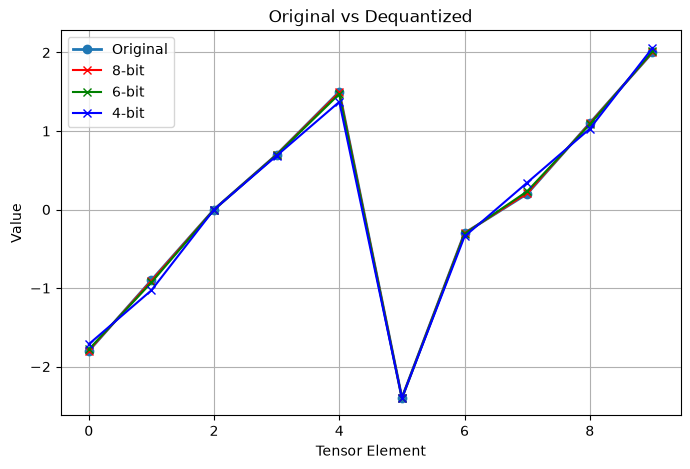

In [7]:
plt.figure(figsize=(8,5))
original = tensor.flatten()
plt.plot(original,
         marker='o',
         linewidth=2,
         label="Original")
colors = ['red','green','blue']
for i, bits in enumerate(bit_widths):
    plt.plot(results[bits]["dequantized"].flatten(),
             marker='x',
             label=f"{bits}-bit",
             color=colors[i])
plt.title("Original vs Dequantized")
plt.xlabel("Tensor Element")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

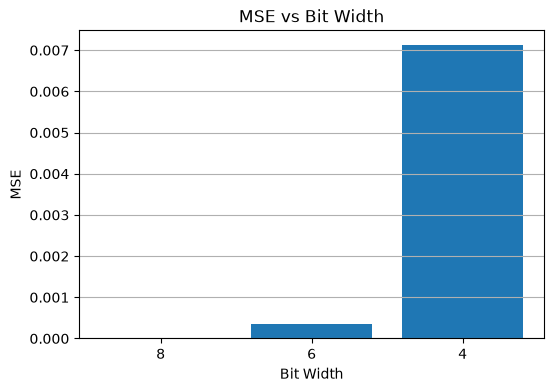

In [8]:
mse_values = [results[b]["mse"] for b in bit_widths]
plt.figure(figsize=(6,4))
plt.bar(
    [str(b) for b in bit_widths],
    mse_values
)
plt.title("MSE vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("MSE")
plt.grid(axis='y')
plt.show()

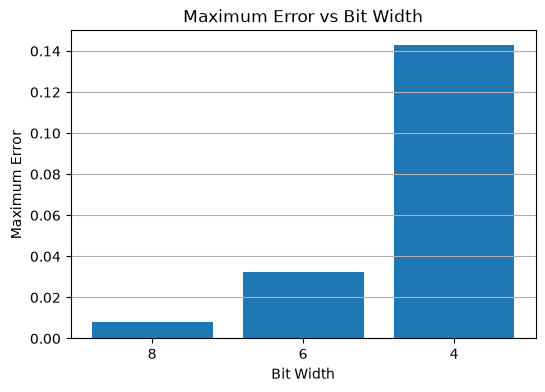

In [9]:
max_errors = [results[b]["max_error"] for b in bit_widths]
plt.figure(figsize=(6,4))
plt.bar(
    [str(b) for b in bit_widths],
    max_errors
)
plt.title("Maximum Error vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Maximum Error")
plt.grid(axis='y')
plt.show()

Observation

The 8-bit quantization produced the smallest reconstruction error because it has the highest number of representable values. As the bit width was reduced to 6-bit and 4-bit, the scale increased and the quantization error became larger. This shows that lower bit widths reduce memory usage but also reduce numerical precision.